# ReasonVLM - Deep Schema Grounding (DSG)
This notebook explores grounding abstract concepts in mathematical graphs using the DSG framework.

In [1]:
# 1. Setup - Install necessary packages
!pip install datasets pillow matplotlib requests

In [2]:
# 2. Import modular utilities
from data_utils import download_dynamath, filter_by_subject, display_item

print("Utilities imported successfully.")

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
# 3. Download the DynaMath Sample dataset
dataset = download_dynamath(split='sample_variant1')

NameError: name 'download_dynamath' is not defined

In [4]:
# 4. Filter for 'analytic geometry' (Graphs)
graph_dataset = filter_by_subject(dataset, 'analytic geometry')

Filtered dataset to 97 items with subject 'analytic geometry'.


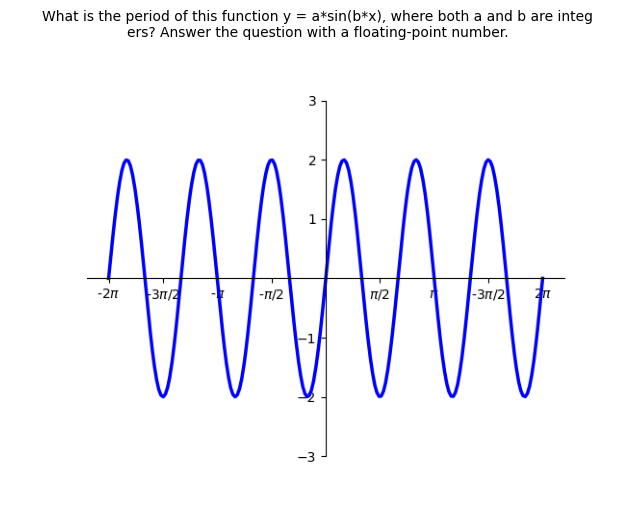

Subject: analytic geometry | Category: Unknown


In [5]:
# 5. Visualize a sample item
if len(graph_dataset) > 0:
    sample_item = graph_dataset[0]
    display_item(sample_item)
else:
    print("No items found in the filtered dataset.")

In [6]:
import os
import pandas as pd
from dsg_math_solver import solve_graph_problem
from data_utils import get_item_data
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

results = []
num_to_test = 5

print(f"--- STARTING BATCH EVALUATION ({num_to_test} items) ---\n")

for i in range(min(num_to_test, len(graph_dataset))):
    item = graph_dataset[i]
    question, img, answer_type, ground_truth = get_item_data(item)
    
    print(f"[{i+1}/{num_to_test}] Solving: {question[:50]}...")
    
    try:
        # Run the new precision-refined DSG
        dsg_result = solve_graph_problem(img, question, answer_type=answer_type, api_key=api_key, verbose=False)
        
        results.append({
            "Index": i,
            "Question": question,
            "Ground Truth": ground_truth,
            "DSG Answer": dsg_result["answer"],
            "Match": str(ground_truth).strip() == str(dsg_result["answer"]).strip()
        })
        print(f"   Done. Answer: {dsg_result['answer']}\n")
    except Exception as e:
        print(f"   Error on item {i}: {e}\n")

# Display Summary Table
df_results = pd.DataFrame(results)
display(df_results)


--- STARTING BATCH EVALUATION (5 items) ---

[1/5] Solving: What is the period of this function y = a*sin(b*x)...
   Done. Answer: 6.283

[2/5] Solving: Is this a periodic function? Choices: (A) Yes (B) ...
   Done. Answer: A

[3/5] Solving: What is the period of this function y = a*cos(b*x)...
   Done. Answer: 6.283

[4/5] Solving: The period of the red curve is ____ that of the bl...
   Done. Answer: C

[5/5] Solving: how many zeros this function has? choice: (A) 2 (B...
   Done. Answer: B



,Index,Question,Ground Truth,DSG Answer,Match
0,0,What is the period of this function y = a*sin(...,2.0944,6.283,False
1,1,Is this a periodic function? Choices: (A) Yes ...,A,A,True
2,2,What is the period of this function y = a*cos(...,3.1416,6.283,False
3,3,The period of the red curve is ____ that of th...,C,C,True
4,4,how many zeros this function has? choice: (A) ...,B,B,True


In [7]:
# Select the first failing item (Index 0)
item = graph_dataset[0]
question, img, answer_type, ground_truth = get_item_data(item)

print(f"DEBUGGING ITEM 0")
print(f"EXPECTED: {ground_truth}\n")

# Run with verbose=True to see every grounding step
dsg_result = solve_graph_problem(img, question, answer_type=answer_type, api_key=api_key, verbose=True)

print("\n--- FINAL DSG OUTPUT ---")
print(f"Solution: {dsg_result['solution']}")
print(f"Final Answer: {dsg_result['answer']}")


DEBUGGING ITEM 0
EXPECTED: 2.0944

Parsing Generic Graph Program...
Starting Grounding Loop for Concept: math-graph
Querying [axes limits and labels]: Imagine that the image represents math-graph, what is the axes limits and labels? Answer with one word or phrase only, do not elaborate.
Answer: -2π to 2π, -3 to 3
Querying [origin location and grid increments]: Imagine that the image represents math-graph and the axes limits and labels is -2π to 2π, -3 to 3, what is the origin location and grid increments? Answer with one word or phrase only, do not elaborate.
Answer: origin: center; increments: π/2, 1
Querying [curve type and qualitative shape]: Imagine that the image represents math-graph and the origin location and grid increments is origin: center; increments: π/2, 1, what is the curve type and qualitative shape? Answer with one word or phrase only, do not elaborate.
Answer: sinewave
Querying [precise coordinates of intercepts and extrema]: Imagine that the image represents math-gra

In [4]:
!git clone https://github.com/Vasudev08/reasonvlm.git

Cloning into 'reasonvlm'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 110 (delta 42), reused 89 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 2.04 MiB | 5.67 MiB/s, done.
Resolving deltas: 100% (42/42), done.


In [8]:
%cd reasonvlm/

/content/reasonvlm


In [9]:
import os
import pandas as pd
from dsg_math_solver import solve_graph_problem
from data_utils import get_item_data, download_dynamath, filter_by_subject
from dotenv import load_dotenv
from PIL import Image
from viser_utils import apply_viser_scaffolding

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

# 1. Select a challenging item from your existing graph_dataset
item = graph_dataset[0] 
question, img, answer_type, ground_truth = get_item_data(item)

print(f"Question: {question}")
print(f"Ground Truth: {ground_truth}\n")

# 2. Solve without VISER
print("--- Running Standard DSG ---")
res_standard = solve_graph_problem(img, question, answer_type=answer_type, use_viser=False, verbose=True)

# 3. Solve with VISER
print("\n--- Running VISER-Enhanced DSG ---")
res_viser = solve_graph_problem(img, question, answer_type=answer_type, use_viser=True, verbose=True)

print("\n--- COMPARISON ---")
print(f"Standard DSG Answer: {res_standard['answer']}")
print(f"VISER DSG Answer: {res_viser['answer']}")

# 4. Visualize the VISER scaffolding to see what the model sees
print("\nVisual Scaffolding Applied to Image:")
viser_img = apply_viser_scaffolding(img)
display(viser_img)


IndentationError: expected an indented block after 'else' statement on line 295 (dsg_utils.py, line 297)